# Análisis de datos con lubridate, dplyr y tidyr

La actividad consiste en realizar un análisis exploratorio utilizando las librerías dplyr, lubridate y tidyr sobre el conjunto de datos de llamadas al 911 de la CDMX. El número de emergencias 911 es un servicio público mediante el cual se brinda atención a la ciudadanía, en coordinación con diversas dependencias, en temas relacionados con delitos, emergencias, faltas cívicas, servicios públicos y urgencias médicas. 

El análisis se llevará a cabo con los datos incluidos en el recurso [dataset_911](./dataset_911), que contiene información de las llamadas al 911 correspondientes al primer y segundo semestre de 2021, así como al primer semestre de 2022. Para garantizar una correcta interpretación, se recomienda consultar el diccionario de datos y el manual de usuario disponibles en el archivo. Los datos también pueden ser consultados en: [https://datos.cdmx.gob.mx/dataset/llamadas-numero-de-atencion-a-emergencias-911](https://datos.cdmx.gob.mx/dataset/llamadas-numero-de-atencion-a-emergencias-911)

Los alumnos deberán explorar el conjunto de datos y extraer información relevante, presentando hallazgos significativos mediante gráficos y análisis que respalden sus conclusiones. Se espera que los alumnos realicen al menos las siguientes tareas:

1. Agrupa los incidentes por mes y alcaldía, y calcula el número promedio de incidentes por categoría.
2. Identifica el día de la semana con más incidentes y determinar el total de llamadas para ese día. 
3. Crea un análisis temporal que muestre la distribución de incidentes por hora del día para las categorías "DELITO", "EMERGENCIA" y "URGENCIA MÉDICA". Utiliza gráficos adecuados para el análisis.
4. Calcula el tiempo promedio entre la creación y cierre del incidente (usa fecha_creacion y fecha_cierre). Así mismo, determinar el tiempo mínimo y máximo.
5. Determinar el porcentaje de llamadas que fueron clasificadas como "Falsa Alarma".


## Configuración del entorno

Para este análisis se utilizan las siguientes librerías de R:

- **readr**: Lectura eficiente de archivos CSV de gran tamaño.
- **dplyr**: Manipulación y transformación de datos con gramática declarativa.
- **lubridate**: Parseo y aritmética de fechas y horas.
- **tidyr**: Reorganización de datos al formato *tidy*.
- **ggplot2**: Creación de visualizaciones de alta calidad.
- **scales**: Formato de ejes y etiquetas en gráficas.

In [18]:
library(readr)
library(dplyr)
library(lubridate)
library(tidyr)
library(ggplot2)
library(scales)

## Carga y preprocesamiento de datos

Se cargan los tres archivos CSV con información de llamadas al 911 correspondientes al
primer y segundo semestre de 2021 y al primer semestre de 2022. Posteriormente se
combinan en un único dataframe y se preprocesa la información temporal.

In [19]:
ruta <- "dataset_911/"

df1 <- read_csv(paste0(ruta, "llamadas_911_2021_s1.csv"),
                locale = locale(encoding = "Latin1"),
                show_col_types = FALSE)
df2 <- read_csv(paste0(ruta, "llamadas_911_2021_s2.csv"),
                locale = locale(encoding = "Latin1"),
                show_col_types = FALSE)
df3 <- read_csv(paste0(ruta, "llamadas_911_2022_s1.csv"),
                locale = locale(encoding = "Latin1"),
                show_col_types = FALSE)

df <- bind_rows(df1, df2, df3)
rm(df1, df2, df3)

cat("Total de registros:", format(nrow(df), big.mark = ","), "\n")
cat("Columnas disponibles:\n")
cat(paste(names(df), collapse = ", "), "\n")

Total de registros: 1,671,036 
Columnas disponibles:
folio, categoria_incidente_c4, incidente_c4, anio_creacion, mes_creacion, fecha_creacion, hora_creacion, anio_cierre, mes_cierre, fecha_cierre, hora_cierre, codigo_cierre, clas_con_f_alarma, alcaldia_cierre, colonia_cierre, manzana, latitud, longitud 


In [20]:
# Parseo de fechas (YYYY-MM-DD) y horas (HH:MM:SS) con lubridate
dias_semana <- c("Lunes", "Martes",
                 "Miércoles", "Jueves",
                 "Viernes", "Sábado", "Domingo")

df <- df %>%
  mutate(
    fecha_creacion_dt = ymd(fecha_creacion),
    fecha_cierre_dt   = ymd(fecha_cierre),
    datetime_creacion = ymd_hms(paste(fecha_creacion, hora_creacion)),
    datetime_cierre   = ymd_hms(paste(fecha_cierre,   hora_cierre)),
    hora_del_dia      = hour(hms(hora_creacion)),
    dia_semana_num    = wday(fecha_creacion_dt, week_start = 1),
    dia_semana        = dias_semana[dia_semana_num]
  )

cat("Registros con fecha válida:",
    format(sum(!is.na(df$fecha_creacion_dt)), big.mark = ","), "\n")
cat("Rango de fechas:",
    format(min(df$fecha_creacion_dt, na.rm = TRUE)), "a",
    format(max(df$fecha_creacion_dt, na.rm = TRUE)), "\n")

glimpse(df)

Registros con fecha válida: 1,671,036 
Rango de fechas: 2020-03-07 a 2022-04-30 
Rows: 1,671,036
Columns: 25
$ folio                  <chr> "C5/210101/00016", "C5/210101/00277", "C5/21010…
$ categoria_incidente_c4 <chr> "Disturbio", "Servicios", "Disturbio", "Incendi…
$ incidente_c4           <chr> "Disparos", "Alarma activada", "Quema de pirote…
$ anio_creacion          <dbl> 2021, 2021, 2021, 2021, 2021, 2021, 2021, 2021,…
$ mes_creacion           <chr> "Enero", "Enero", "Enero", "Enero", "Enero", "E…
$ fecha_creacion         <date> 2021-01-01, 2021-01-01, 2021-01-01, 2021-01-01…
$ hora_creacion          <time> 00:01:53, 00:30:45, 00:37:41, 00:41:24, 01:21:…
$ anio_cierre            <dbl> 2021, 2021, 2021, 2021, 2021, 2021, 2021, 2021,…
$ mes_cierre             <chr> "Enero", "Enero", "Enero", "Enero", "Enero", "E…
$ fecha_cierre           <date> 2021-01-01, 2021-01-01, 2021-01-01, 2021-01-01…
$ hora_cierre            <time> 00:20:04, 00:46:45, 00:51:07, 03:21:02, 01:54:…
$ codigo_ci

## Tarea 1: Incidentes por mes y alcaldía

Se agrupan los incidentes por año-mes, alcaldía y categoría para obtener el conteo
mensual por grupo. Luego se calcula el **promedio mensual** de incidentes para cada
combinación de alcaldía y categoría.

In [21]:
tarea1 <- df %>%
  group_by(anio_creacion, mes_creacion,
           alcaldia_cierre, clas_con_f_alarma) %>%
  summarise(num_incidentes = n(), .groups = "drop") %>%
  group_by(alcaldia_cierre, clas_con_f_alarma) %>%
  summarise(
    promedio_mensual = round(mean(num_incidentes), 1),
    .groups = "drop"
  ) %>%
  filter(!is.na(alcaldia_cierre), !is.na(clas_con_f_alarma)) %>%
  arrange(desc(promedio_mensual))

cat("Promedio mensual de incidentes por alcaldía y categoría (top 20):\n")
print(head(tarea1, 20))

Promedio mensual de incidentes por alcaldía y categoría (top 20):
# A tibble: 20 × 3
   alcaldia_cierre     clas_con_f_alarma    promedio_mensual
   <chr>               <chr>                           <dbl>
 1 IZTAPALAPA          "DELITO"                        4427.
 2 IZTAPALAPA          "FALTA CÍVICA"                  3523.
 3 IZTAPALAPA          "FALTA CÃ\u008dVICA"            3337.
 4 GUSTAVO A. MADERO   "FALTA CÃ\u008dVICA"            2918.
 5 GUSTAVO A. MADERO   "FALTA CÍVICA"                  2859.
 6 IZTAPALAPA          "SERVICIO"                      2678.
 7 GUSTAVO A. MADERO   "DELITO"                        2584.
 8 GUSTAVO A. MADERO   "SERVICIO"                      2536.
 9 CUAUHTEMOC          "SERVICIO"                      2439.
10 CUAUHTEMOC          "DELITO"                        2205.
11 CUAUHTEMOC          "FALTA CÃ\u008dVICA"            2200.
12 IZTAPALAPA          "URGENCIAS MEDICAS"             2185 
13 COYOACAN            "FALTA CÍVICA"                  2125.


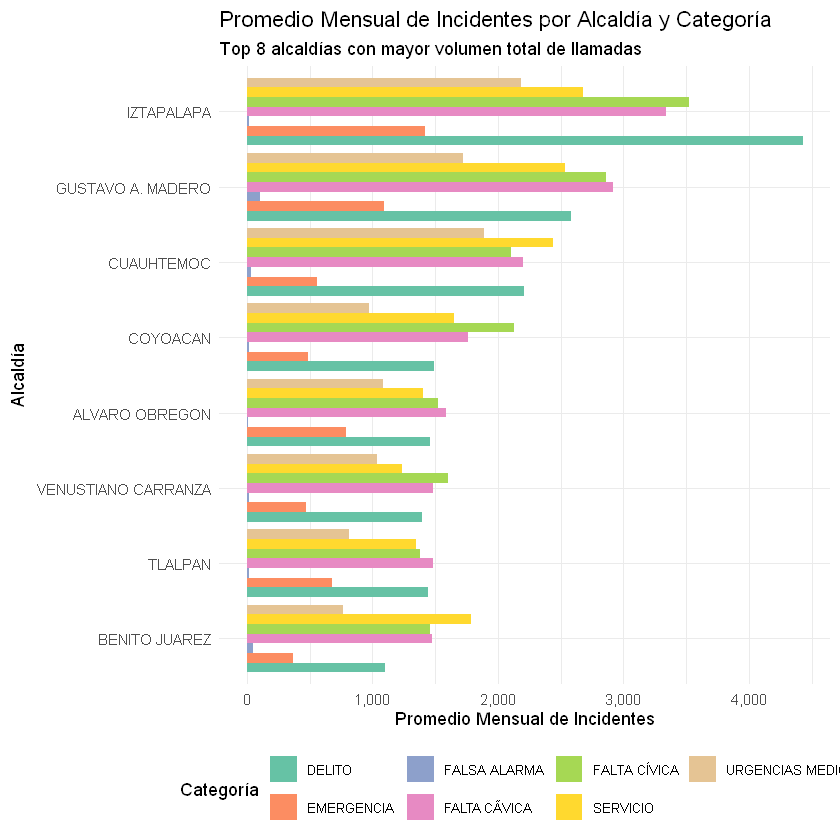

In [22]:
top_alcaldias <- tarea1 %>%
  group_by(alcaldia_cierre) %>%
  summarise(total = sum(promedio_mensual), .groups = "drop") %>%
  slice_max(total, n = 8) %>%
  pull(alcaldia_cierre)

tarea1_plot <- tarea1 %>%
  filter(alcaldia_cierre %in% top_alcaldias)

ggplot(tarea1_plot,
       aes(x    = reorder(alcaldia_cierre, promedio_mensual),
           y    = promedio_mensual,
           fill = clas_con_f_alarma)) +
  geom_col(position = "dodge") +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = "Promedio Mensual de Incidentes por Alcaldía y Categoría",
    subtitle = "Top 8 alcaldías con mayor volumen total de llamadas",
    x        = "Alcaldía",
    y        = "Promedio Mensual de Incidentes",
    fill     = "Categoría"
  ) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "bottom",
        legend.text     = element_text(size = 8))

## Tarea 2: Día de la semana con más incidentes

Se agregan todas las llamadas por día de la semana para identificar cuál concentra
el mayor número de incidentes y se reporta el total de llamadas para ese día.

In [23]:
tarea2 <- df %>%
  filter(!is.na(dia_semana)) %>%
  group_by(dia_semana_num, dia_semana) %>%
  summarise(total_llamadas = n(), .groups = "drop") %>%
  arrange(dia_semana_num)

dia_max <- tarea2 %>% slice_max(total_llamadas, n = 1)

cat("Día con más incidentes:", dia_max$dia_semana, "\n")
cat("Total de llamadas ese día: ",
    format(dia_max$total_llamadas, big.mark = ","), "\n\n")
print(tarea2)

Día con más incidentes: Sábado 
Total de llamadas ese día:  325,184 

# A tibble: 7 × 3
  dia_semana_num dia_semana total_llamadas
           <dbl> <chr>               <int>
1              1 Lunes              202136
2              2 Martes             183461
3              3 Miércoles          192211
4              4 Jueves             201600
5              5 Viernes            241517
6              6 Sábado             325184
7              7 Domingo            324927


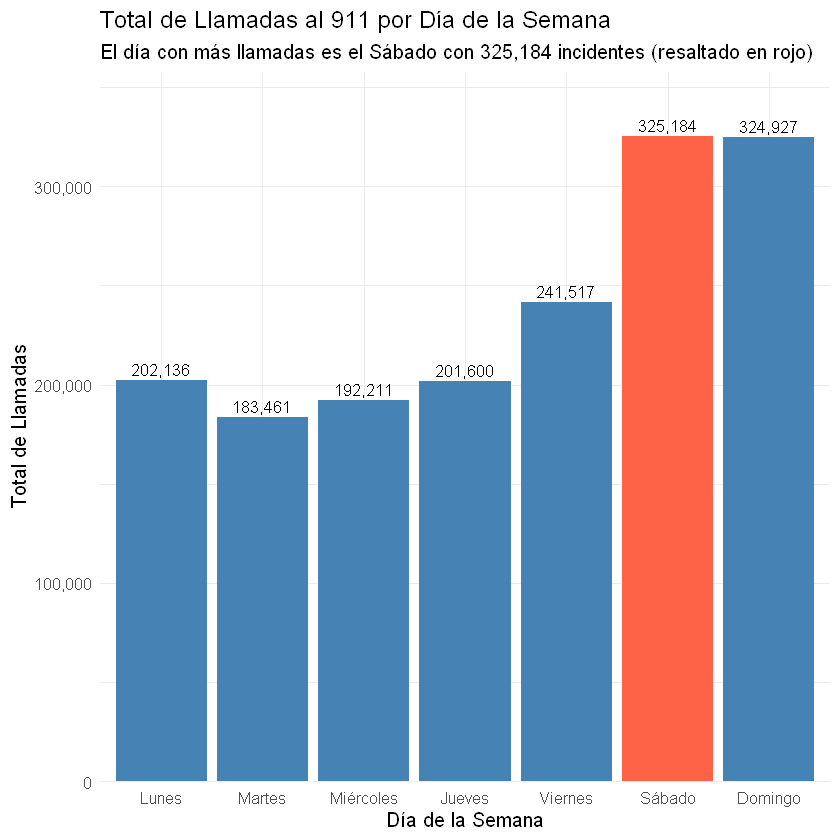

In [24]:
ggplot(tarea2,
       aes(x    = factor(dia_semana, levels = dias_semana),
           y    = total_llamadas,
           fill = dia_semana == dia_max$dia_semana)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = format(total_llamadas, big.mark = ",")),
            vjust = -0.4, size = 3.5) +
  scale_y_continuous(labels  = comma,
                     expand  = expansion(mult = c(0, 0.1))) +
  scale_fill_manual(values = c("FALSE" = "steelblue", "TRUE" = "tomato")) +
  labs(
    title    = "Total de Llamadas al 911 por Día de la Semana",
    subtitle = paste0("El día con más llamadas es el ", dia_max$dia_semana,
                      " con ", format(dia_max$total_llamadas, big.mark = ","),
                      " incidentes (resaltado en rojo)"),
    x        = "Día de la Semana",
    y        = "Total de Llamadas"
  ) +
  theme_minimal(base_size = 12)

## Tarea 3: Distribución de incidentes por hora del día

Se analiza la distribución horaria de los incidentes para las categorías **DELITO**,
**EMERGENCIA** y **URGENCIA MÉDICA**, lo que permite identificar los momentos del día
con mayor demanda para cada tipo de incidente.

In [25]:
categorias_presentes <- df %>%
  filter(grepl("DELITO|EMERGENCIA|URGENCIA",
               clas_con_f_alarma)) %>%
  distinct(clas_con_f_alarma) %>%
  pull(clas_con_f_alarma)

cat("Categorías encontradas en los datos:\n")
print(categorias_presentes)

tarea3 <- df %>%
  filter(grepl("DELITO|EMERGENCIA|URGENCIA",
               clas_con_f_alarma),
         !is.na(hora_del_dia)) %>%
  group_by(hora_del_dia, clas_con_f_alarma) %>%
  summarise(num_incidentes = n(), .groups = "drop")

cat("\nDistribución por hora (primeras filas):\n")
print(head(tarea3, 12))

Categorías encontradas en los datos:
[1] "DELITO"            "EMERGENCIA"        "URGENCIAS MEDICAS"

Distribución por hora (primeras filas):
# A tibble: 12 × 3
   hora_del_dia clas_con_f_alarma num_incidentes
          <dbl> <chr>                      <int>
 1            0 DELITO                     22089
 2            0 EMERGENCIA                  3551
 3            0 URGENCIAS MEDICAS           9304
 4            1 DELITO                     18861
 5            1 EMERGENCIA                  2742
 6            1 URGENCIAS MEDICAS           7734
 7            2 DELITO                     14674
 8            2 EMERGENCIA                  2036
 9            2 URGENCIAS MEDICAS           6448
10            3 DELITO                     11944
11            3 EMERGENCIA                  1602
12            3 URGENCIAS MEDICAS           5352


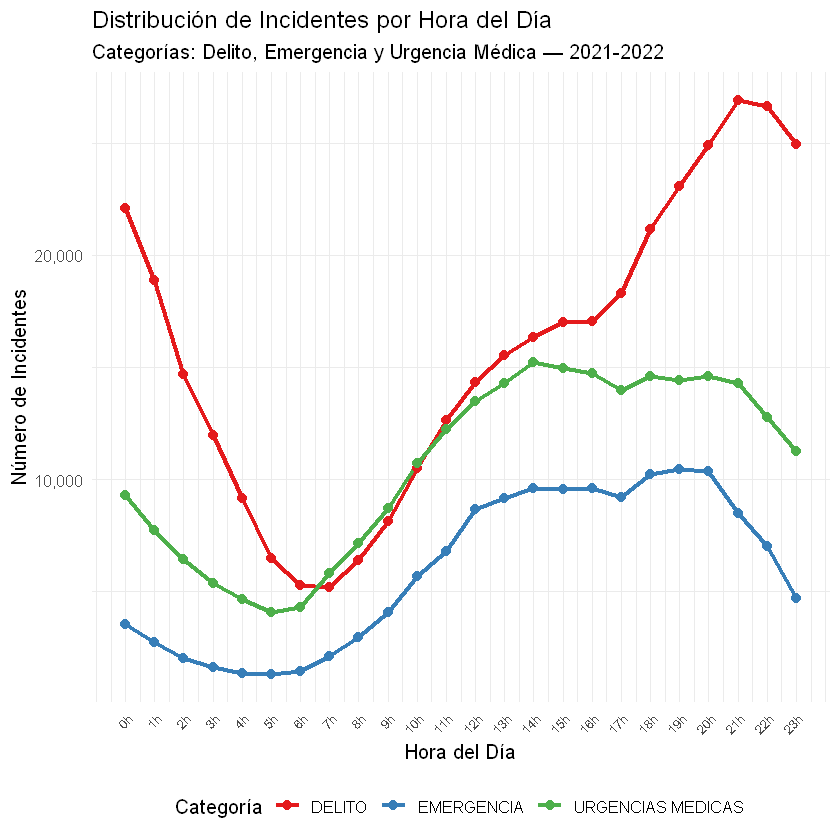

In [26]:
ggplot(tarea3,
       aes(x     = hora_del_dia,
           y     = num_incidentes,
           color = clas_con_f_alarma,
           group = clas_con_f_alarma)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  scale_x_continuous(breaks = 0:23,
                     labels = paste0(0:23, "h")) +
  scale_y_continuous(labels = comma) +
  scale_color_brewer(palette = "Set1") +
  labs(
    title    = "Distribución de Incidentes por Hora del Día",
    subtitle = "Categorías: Delito, Emergencia y Urgencia Médica — 2021-2022",
    x        = "Hora del Día",
    y        = "Número de Incidentes",
    color    = "Categoría"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x     = element_text(angle = 45, hjust = 1, size = 8),
        legend.position = "bottom")

## Tarea 4: Tiempo entre creación y cierre del incidente

Se calcula el tiempo transcurrido entre la apertura (`fecha_creacion` + `hora_creacion`)
y el cierre (`fecha_cierre` + `hora_cierre`) de cada incidente, reportando las
estadísticas de promedio, mediana, mínimo y máximo.

In [27]:
tarea4 <- df %>%
  filter(!is.na(datetime_creacion), !is.na(datetime_cierre)) %>%
  mutate(
    tiempo_mins = as.numeric(difftime(
      datetime_cierre, datetime_creacion,
      units = "mins"
    ))
  ) %>%
  filter(tiempo_mins >= 0)

stats_tiempo <- tarea4 %>%
  summarise(
    promedio_mins = mean(tiempo_mins, na.rm = TRUE),
    mediana_mins  = median(tiempo_mins, na.rm = TRUE),
    minimo_mins   = min(tiempo_mins, na.rm = TRUE),
    maximo_mins   = max(tiempo_mins, na.rm = TRUE)
  )

cat("Estadísticas del tiempo de atención al incidente:\n")
cat("  Promedio:", round(stats_tiempo$promedio_mins, 2), "minutos\n")
cat("  Mediana: ", round(stats_tiempo$mediana_mins, 2), "minutos\n")
cat("  Mínimo:  ", round(stats_tiempo$minimo_mins, 2), "minutos\n")
cat(
  "  Máximo:  ", round(stats_tiempo$maximo_mins / 60, 2), "horas (",
  round(stats_tiempo$maximo_mins, 0), "minutos)\n"
)


Estadísticas del tiempo de atención al incidente:
  Promedio: 166.32 minutos
  Mediana:  38.9 minutos
  Mínimo:   0.07 minutos
  Máximo:   18100.69 horas ( 1086041 minutos)


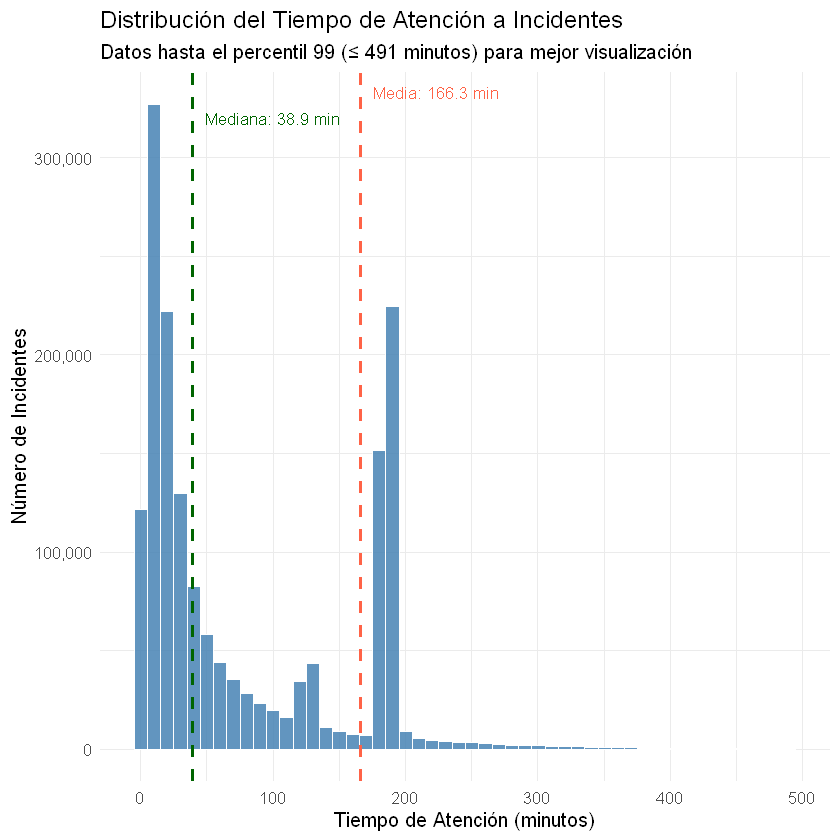

In [28]:
p99 <- quantile(tarea4$tiempo_mins, 0.99, na.rm = TRUE)

ggplot(
  tarea4 %>% filter(tiempo_mins <= p99),
  aes(x = tiempo_mins)
) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white", alpha = 0.85) +
  geom_vline(
    xintercept = stats_tiempo$promedio_mins,
    color = "tomato", linetype = "dashed", linewidth = 1
  ) +
  geom_vline(
    xintercept = stats_tiempo$mediana_mins,
    color = "darkgreen", linetype = "dashed", linewidth = 1
  ) +
  scale_x_continuous(labels = comma) +
  scale_y_continuous(labels = comma) +
  annotate("text",
    x = stats_tiempo$promedio_mins,
    y = Inf,
    label = paste0(
      "Media: ",
      round(stats_tiempo$promedio_mins, 1), " min"
    ),
    vjust = 2, hjust = -0.1, color = "tomato", size = 3.5
  ) +
  annotate("text",
    x = stats_tiempo$mediana_mins,
    y = Inf,
    label = paste0(
      "Mediana: ",
      round(stats_tiempo$mediana_mins, 1), " min"
    ),
    vjust = 4, hjust = -0.1, color = "darkgreen", size = 3.5
  ) +
  labs(
    title = "Distribución del Tiempo de Atención a Incidentes",
    subtitle = paste0(
      "Datos hasta el percentil 99 (≤ ",
      round(p99, 0), " minutos) para mejor visualización"
    ),
    x = "Tiempo de Atención (minutos)",
    y = "Número de Incidentes"
  ) +
  theme_minimal(base_size = 12)


## Tarea 5: Porcentaje de llamadas clasificadas como Falsa Alarma

Se determina la proporción de llamadas que fueron clasificadas como **Falsa Alarma**
con respecto al total de llamadas registradas en el periodo analizado.

In [ ]:
cat("Distribución de valores en clas_con_f_alarma:\n")
df %>%
  count(clas_con_f_alarma, name = "total", sort = TRUE) %>%
  mutate(porcentaje = round(total / sum(total) * 100, 2)) %>%
  print()

Distribucion de valores en clas_con_f_alarma:
# A tibble: 7 × 3
  clas_con_f_alarma     total porcentaje
  <chr>                 <int>      <dbl>
1 "SERVICIO"           462340      27.7 
2 "DELITO"             377511      22.6 
3 "FALTA CÃ\u008dVICA" 304888      18.2 
4 "URGENCIAS MEDICAS"  255041      15.3 
5 "EMERGENCIA"         142646       8.54
6 "FALTA CÍVICA"       128106       7.67
7 "FALSA ALARMA"          504       0.03


In [30]:
total_llamadas   <- nrow(df)
falsa_alarma_n   <- df %>%
  filter(grepl("FALSA ALARMA", clas_con_f_alarma, fixed = TRUE)) %>%
  nrow()

pct_falsa_alarma <- (falsa_alarma_n / total_llamadas) * 100

cat("Total de llamadas registradas:   ",
    format(total_llamadas, big.mark = ","), "\n")
cat("Llamadas clasificadas como Falsa Alarma:",
    format(falsa_alarma_n, big.mark = ","), "\n")
cat("Porcentaje de Falsa Alarma:", round(pct_falsa_alarma, 2), "%\n")

Total de llamadas registradas:    1,671,036 
Llamadas clasificadas como Falsa Alarma: 504 
Porcentaje de Falsa Alarma: 0.03 %


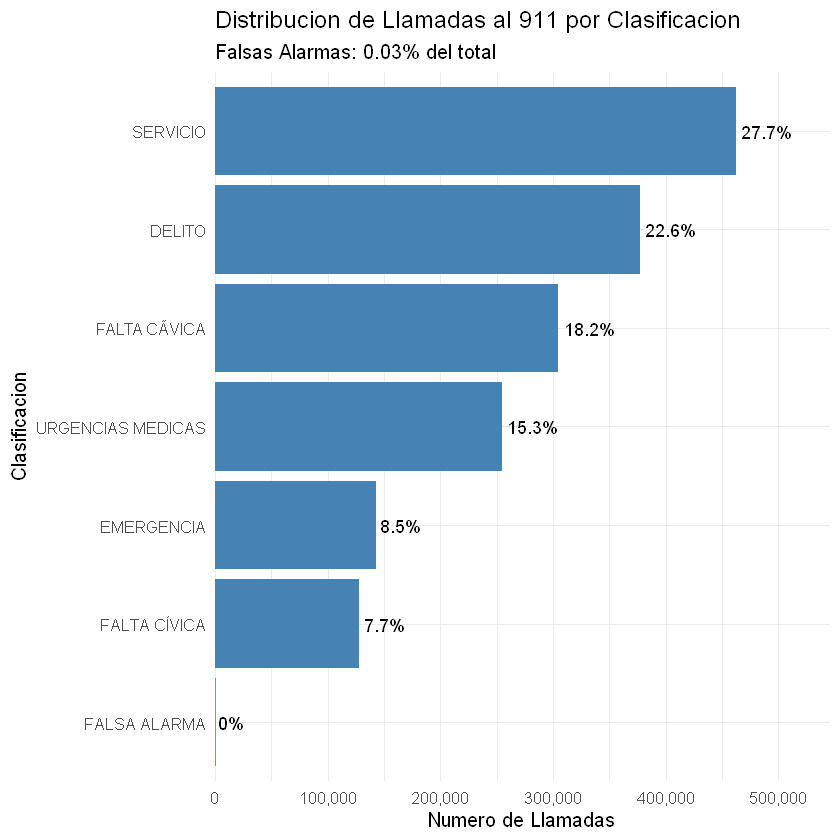

In [ ]:
df_clasificacion <- df %>%
  filter(!is.na(clas_con_f_alarma)) %>%
  count(clas_con_f_alarma, name = "cantidad") %>%
  mutate(
    porcentaje = cantidad / sum(cantidad) * 100,
    es_falsa = grepl("FALSA ALARMA", clas_con_f_alarma,
      fixed = TRUE
    )
  ) %>%
  arrange(desc(cantidad))

ggplot(
  df_clasificacion,
  aes(
    x = reorder(clas_con_f_alarma, cantidad),
    y = cantidad,
    fill = es_falsa
  )
) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0(round(porcentaje, 1), "%")),
    hjust = -0.1, size = 3.8
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = comma,
    expand = expansion(mult = c(0, 0.18))
  ) +
  scale_fill_manual(
    values = c("FALSE" = "steelblue", "TRUE" = "tomato")
  ) +
  labs(
    title = "Distribución de Llamadas al 911 por Clasificacion",
    subtitle = paste0(
      "Falsas Alarmas: ",
      round(pct_falsa_alarma, 2), "% del total"
    ),
    x = "Clasificacion",
    y = "Numero de Llamadas"
  ) +
  theme_minimal(base_size = 12)


## Conclusiones

El análisis exploratorio de las **1,671,036 llamadas al 911 de la CDMX** del periodo
2021 – primer semestre 2022, realizado con `dplyr`, `lubridate`, `tidyr` y `ggplot2`,
permitió identificar los siguientes hallazgos:

1. **Distribución por alcaldía y categoría**: Las alcaldías con mayor volumen mensual de
   incidentes son **Iztapalapa** (oriente), **Gustavo A. Madero** (norte) y **Cuauhtémoc**
   (centro). Iztapalapa lidera con un promedio de 4,427 delitos y 3,523 faltas cívicas por
   mes, lo que refleja su alta densidad poblacional. La distribución varía notablemente
   según la categoría: los delitos y faltas cívicas dominan en el oriente y norte, mientras
   que servicios y urgencias médicas se distribuyen de forma más uniforme.

2. **Día de la semana con más incidentes**: El **sábado** es el día con mayor número de
   llamadas, con **325,184 incidentes**, seguido muy de cerca por el domingo con 324,927.
   Los fines de semana concentran aproximadamente el 39% del total semanal, con una
   diferencia de hasta 60% respecto a los días de menor actividad como martes (183,461)
   y miércoles (192,211). Este patrón sugiere que la mayor actividad nocturna y social
   del fin de semana incrementa significativamente la demanda del servicio.

3. **Distribución horaria**: Los patrones de demanda varían claramente por categoría a lo
   largo del día. Los **delitos** muestran su pico en horas nocturnas (22,089 incidentes a
   medianoche, decayendo progresivamente hasta las 6 a.m.), mientras que las **urgencias
   médicas** mantienen un volumen elevado durante toda la noche y alcanzan su máximo en
   horas diurnas. Las **emergencias** presentan el volumen más bajo de las tres categorías
   en todo momento, con picos moderados durante el día. Estos patrones son útiles para
   planificar la asignación de recursos según la hora.

4. **Tiempo de atención**: Existe alta variabilidad en el tiempo entre creación y cierre
   del incidente. La **mediana es de 38.9 minutos**, considerablemente menor al **promedio
   de 166.32 minutos**, lo que indica que la distribución está fuertemente sesgada a la
   derecha por casos atípicos con tiempos de resolución muy prolongados. El máximo
   registrado asciende a 18,100 horas (~754 días), valor que corresponde a un error en
   los datos o a registros que nunca fueron cerrados correctamente. El tiempo mínimo
   es de 0.07 minutos (~4 segundos), correspondiente a llamadas cerradas casi de inmediato.

5. **Falsa Alarma**: Solo el **0.03%** de las llamadas (504 de 1,671,036) fueron
   clasificadas directamente como Falsa Alarma, lo que representa una proporción
   mínima dentro del total registrado. Las categorías con mayor volumen son
   Servicio (27.7%), Delito (22.6%) y Falta Cívica (~26% sumando ambas codificaciones),
   que en conjunto superan el 75% de todas las llamadas. Aunque las falsas alarmas no
   representan una carga significativa en términos porcentuales, cada evento consume
   recursos de despacho que podrían destinarse a emergencias reales.

## Referencias

### Manipulación y Análisis de Datos en R

1. Wickham, H., François, R., Henry, L., Müller, K., & Vaughan, D. (2023). *dplyr: A Grammar of Data Manipulation*. R package version 1.1.4. CRAN.
   [https://CRAN.R-project.org/package=dplyr](https://CRAN.R-project.org/package=dplyr)

2. Wickham, H., Vaughan, D., & Girlich, M. (2024). *tidyr: Tidy Messy Data*. R package version 1.3.1. CRAN.
   [https://CRAN.R-project.org/package=tidyr](https://CRAN.R-project.org/package=tidyr)

3. Wickham, H. (2016). *ggplot2: Elegant Graphics for Data Analysis*. Springer-Verlag New York.
   [https://ggplot2.tidyverse.org](https://ggplot2.tidyverse.org)

### Manejo de Fechas y Tiempos

4. Spinu, V., Grolemund, G., & Wickham, H. (2023). *lubridate: Make Dealing with Dates a Little Easier*. R package version 1.9.3. CRAN.
   [https://CRAN.R-project.org/package=lubridate](https://CRAN.R-project.org/package=lubridate)

5. Grolemund, G., & Wickham, H. (2011). Dates and Times Made Easy with lubridate. *Journal of Statistical Software*, 40(3), 1–25.
   [https://www.jstatsoft.org/v40/i03/](https://www.jstatsoft.org/v40/i03/)

### Ciencia de Datos con R

6. Wickham, H., Çetinkaya-Rundel, M., & Grolemund, G. (2023). *R for Data Science* (2.ª ed.). O'Reilly Media.
   [https://r4ds.had.co.nz/](https://r4ds.had.co.nz/)

### Dataset

7. Gobierno de la Ciudad de México. (2022). *Llamadas al número de atención a emergencias 911* [Conjunto de datos]. Portal de Datos Abiertos de la CDMX.
   [https://datos.cdmx.gob.mx/dataset/llamadas-numero-de-atencion-a-emergencias-911](https://datos.cdmx.gob.mx/dataset/llamadas-numero-de-atencion-a-emergencias-911)

### Repositorio del Proyecto

8. RKCbas. (2024). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub.
   [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/5%20-%20Lenguajes%20de%20ciencia%20de%20datos%20avanzado/Practica%203.1/An%C3%A1lisis%20de%20datos%20con%20lubridate%2C%20dplyr%20y%20tidyr.ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/5%20-%20Lenguajes%20de%20ciencia%20de%20datos%20avanzado/Practica%203.1/An%C3%A1lisis%20de%20datos%20con%20lubridate%2C%20dplyr%20y%20tidyr.ipynb)